# Validation finale — Prédiction du Churn Client

Ce notebook constitue le troisième livrable : validation du modèle retenu sur le jeu de
test, jamais utilisé jusqu'ici, avec analyse de sa capacité à généraliser.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

sns.set_theme(style="whitegrid")

# --- Palette (reprise, kernel séparé) ---
COULEUR_RESTE = "#2a78d6"
COULEUR_CHURN = "#eb6834"

# --- Rechargement du modèle final et du jeu de test ---
modele_final = joblib.load("../models/random_forest_final.pkl")

with open("../models/random_forest_final_meta.json") as f:
    meta = json.load(f)

test_df = pd.read_csv("../data/processed/test.csv")
X_test = test_df.drop(columns=["Churn"])
y_test = test_df["Churn"]

print("Hyperparamètres du modèle final :", meta["best_params"])
print(f"AUC en validation croisée (train) : {meta['cv_auc_mean']:.3f}")
print(X_test.shape)

Hyperparamètres du modèle final : {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 200}
AUC en validation croisée (train) : 0.848
(1409, 19)


## 1. Chargement du modèle final et du jeu de test

Le jeu de test est ouvert **une seule fois**, ici, à la toute fin du projet — aucune
décision de modélisation n'a été prise en le consultant.

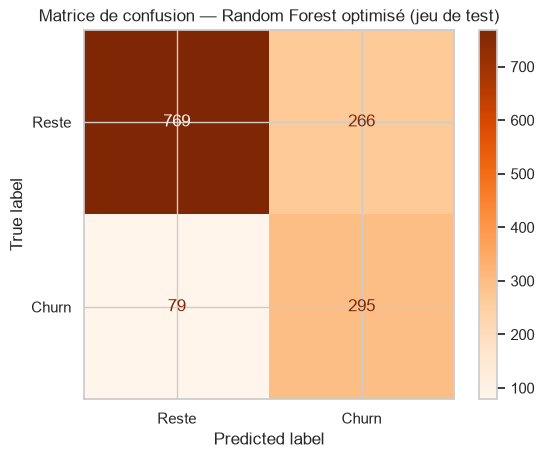

              precision    recall  f1-score   support

       Reste       0.91      0.74      0.82      1035
       Churn       0.53      0.79      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.76      0.77      1409

AUC (test)                      : 0.845
AUC (validation croisée, train) : 0.848
Écart                           : 0.003


In [2]:
# ============================================================
# VALIDATION FINALE — le jeu de TEST est ouvert ici, une seule fois.
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve

y_pred_test = modele_final.predict(X_test)
y_proba_test = modele_final.predict_proba(X_test)[:, 1]

# --- Matrice de confusion ---
cm_test = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm_test, display_labels=["Reste", "Churn"]).plot(cmap="Oranges")
plt.title("Matrice de confusion — Random Forest optimisé (jeu de test)")
plt.show()

# --- Rapport complet ---
print(classification_report(y_test, y_pred_test, target_names=["Reste", "Churn"]))

# --- AUC test vs AUC de validation croisée : indicateur clé de généralisation ---
auc_test = roc_auc_score(y_test, y_proba_test)
print(f"AUC (test)                      : {auc_test:.3f}")
print(f"AUC (validation croisée, train) : {meta['cv_auc_mean']:.3f}")
print(f"Écart                           : {abs(auc_test - meta['cv_auc_mean']):.3f}")

## 2. Résultats sur le jeu de test

**AUC (test) = 0,845**, à comparer à l'AUC de validation croisée (0,848) obtenue sur le
train — écart de 0,003, négligeable. **Conclusion sur la généralisation** : le modèle ne
surapprend pas ; la performance mesurée pendant le développement se confirme sur des
données jamais vues.

Au seuil de décision par défaut (0,5) : rappel de 0,79 sur la classe Churn (le modèle
détecte 4 churners sur 5), précision de 0,53.

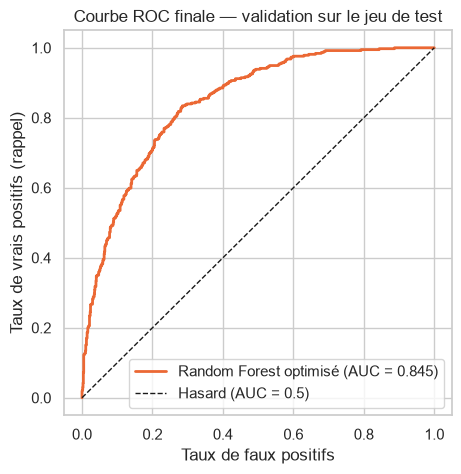

In [3]:
# --- Courbe ROC finale ---
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color=COULEUR_CHURN, linewidth=2, label=f"Random Forest optimisé (AUC = {auc_test:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Hasard (AUC = 0.5)")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs (rappel)")
plt.title("Courbe ROC finale — validation sur le jeu de test")
plt.legend()
plt.show()

## 3. Analyse du seuil de décision

Le F1-score est déjà maximal au seuil par défaut (0,5). Si l'entreprise souhaite
prioriser la détection maximale des churners (cohérent avec le coût métier asymétrique),
un seuil de 0,3 permettrait de pousser le rappel à 0,91, au prix d'une précision réduite
à 0,43 — un arbitrage à présenter comme option, pas comme réponse unique.

In [4]:
# --- Effet du seuil de décision sur le test, pour la discussion du compromis métier ---
from sklearn.metrics import precision_score, recall_score, f1_score

lignes = []
for seuil in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_s = (y_proba_test >= seuil).astype(int)
    lignes.append({
        "seuil": seuil,
        "précision": round(precision_score(y_test, y_pred_s), 3),
        "rappel": round(recall_score(y_test, y_pred_s), 3),
        "F1": round(f1_score(y_test, y_pred_s), 3),
    })
pd.DataFrame(lignes)

,seuil,précision,rappel,F1
0,0.3,0.430,0.912,0.584
1,0.4,0.473,0.853,0.609
2,0.5,0.526,0.789,0.631
3,0.6,0.582,0.666,0.621
4,0.7,0.661,0.516,0.580


## 4. Conclusions

Le modèle retenu (Random Forest, `class_weight="balanced"`, `min_samples_leaf=10`,
`n_estimators=200`) atteint une AUC de 0,845 sur le jeu de test, confirmant une bonne
capacité de généralisation. Il privilégie le rappel (0,79) sur la précision (0,53), un
choix cohérent avec le coût métier du churn : un client non détecté coûte davantage
qu'une action de rétention proposée à tort. Le seuil de décision reste un levier
supplémentaire, à ajuster selon la stratégie commerciale de l'entreprise.